intallations


In [1]:
!pip install torch torchvision matplotlib scikit-learn transformers

In [14]:
!pip install wandb
import wandb

wandb.login()


True

In [ ]:
# wandb.login(key="avital's_key")

imports

In [4]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

drive + paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Clone repo
!git clone https://github.com/AvitalSkop/genai-project.git
%cd genai-project

base_dir = "/content/drive/MyDrive/genai_project/data/split"

# train_dir = f"{base_dir}/train"
# val_dir   = f"{base_dir}/val"
# test_dir  = f"{base_dir}/test"

real_test_dir = "/content/drive/MyDrive/genai_project/data/real_test"

Mounted at /content/drive
Cloning into 'genai-project'...
remote: Enumerating objects: 380, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 380 (delta 64), reused 54 (delta 45), pack-reused 299 (from 1)
Receiving objects: 100% (380/380), 19.94 MiB | 12.79 MiB/s, done.
Resolving deltas: 100% (185/185), done.
/content/genai-project


copy to local

In [ ]:
import shutil
import os

SRC = "/content/drive/MyDrive/genai_project/data/split"
DST = "/content/data"

if not os.path.exists(DST):
    print("Copying data to local...")
    shutil.copytree(SRC, DST)
    print("Done copying")
else:
    print("Local data already exists")

In [ ]:
import time

start = time.time()
for images, _ in train_loader:
    break

print("Time to first batch:", time.time() - start)

transforms

In [6]:
from torchvision import transforms
import torch

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomRotation(8),

    transforms.RandomPerspective(
        distortion_scale=0.08,
        p=0.3
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.1,
        hue=0.02
    ),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 0.4)
    ),

    transforms.ToTensor(),

    transforms.Lambda(
        lambda x: torch.clamp(
            x + 0.01 * torch.randn_like(x),
            0, 1
        )
    ),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

datasets

Classes: ['clean', 'finished', 'full']


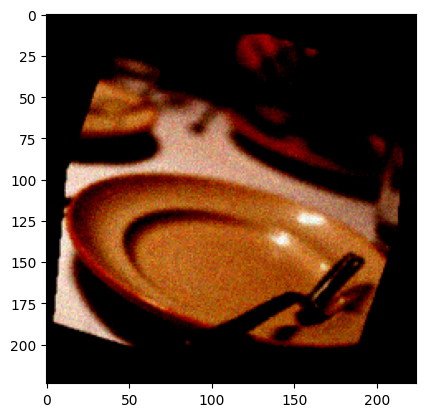

In [9]:
import matplotlib.pyplot as plt

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

real_dataset = datasets.ImageFolder(real_test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=16, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=16, num_workers=0)
real_loader  = DataLoader(real_dataset, batch_size=16, num_workers=0)

print("Classes:", train_dataset.classes)

# check if dataloader is shuffle - different image every time
def show_batch(images, n=8):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))

    for i in range(n):
        img = images[i]

        # 🔥 unnormalize (חשוב!)
        img = img * torch.tensor([0.229,0.224,0.225]).view(3,1,1)
        img = img + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        img = img.clamp(0,1)

        axes[i].imshow(img.permute(1,2,0))
        axes[i].axis("off")

    plt.show()

for images, _ in train_loader:
    show_batch(images, n=8)
    break

In [ ]:
import random
import matplotlib.pyplot as plt

def show_per_class(dataset, classes, n_per_class=5):

    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3*n_per_class, 3*len(classes)))

    for c_idx, cls in enumerate(classes):

        # indices של הקלאס
        indices = [i for i, (_, label) in enumerate(dataset.samples) if dataset.classes[label] == cls]

        chosen = random.sample(indices, n_per_class)

        for i, idx in enumerate(chosen):
            img, _ = dataset[idx]

            # 🔥 unnormalize
            img = img * torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            img = img + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            img = img.clamp(0,1)

            axes[c_idx, i].imshow(img.permute(1,2,0))
            axes[c_idx, i].axis("off")

        axes[c_idx, 0].set_ylabel(cls, fontsize=14)

    plt.tight_layout()
    plt.show()


# שימוש
show_per_class(train_dataset, train_dataset.classes, n_per_class=6)

model

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s]


loss + optimizer

In [11]:
# criterion = nn.CrossEntropyLoss()
from collections import Counter
import torch

labels = [label for _, label in train_dataset.samples]
class_counts = Counter(labels)

total = sum(class_counts.values())
class_weights = [total / class_counts[i] for i in range(len(class_counts))]

class_weights = torch.tensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

train + eval

In [12]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val = 0
patience = 10
counter = 0

def train_epoch(model, loader, optimizer, criterion, device):
  model.train()

  total_loss = 0
  correct = 0
  total = 0

  for x, y in loader:
      x, y = x.to(device), y.to(device)

      optimizer.zero_grad()

      outputs = model(x)
      # print("model ok")
      loss = criterion(outputs, y)

      loss.backward()
      optimizer.step()

      total_loss += loss.item() * x.size(0)
      preds = outputs.argmax(1)

      correct += (preds == y).sum().item()
      total += y.size(0)

  avg_loss = total_loss / total
  acc = correct / total

  return avg_loss, acc


def eval_model(model, loader, criterion, device):
  model.eval()

  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
      for x, y in loader:
          x, y = x.to(device), y.to(device)

          outputs = model(x)
          loss = criterion(outputs, y)

          total_loss += loss.item() * x.size(0)

          preds = outputs.argmax(1)
          correct += (preds == y).sum().item()
          total += y.size(0)

  avg_loss = total_loss / total
  acc = correct / total

  return avg_loss, acc

Training (Linear Probe)

In [18]:
wandb.init(
    project="plate-classification",
    name="resnet_lp_augmented",
    config={
        "epochs": 50,
        "batch_size": 16,
        "lr": 1e-4,
        "model": "resnet18",
        "classes": train_dataset.classes
    }
)

In [12]:
import os

BASE_DIR = "/content/drive/MyDrive/genai_project"

CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_lp_path = os.path.join(CHECKPOINT_DIR, "best_model_lp.pth")

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 50
best_val = 0
patience = 10
counter = 0

print("Starting training...")

for epoch in range(epochs):
  train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
  val_loss, val_acc = eval_model(model, val_loader, criterion, device)

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  val_losses.append(val_loss)
  val_accuracies.append(val_acc)

  print(f"Epoch {epoch+1}")
  print(f"Train Loss: {train_loss:.3f} | Train Acc:  {train_acc:.3f} | Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.3f}")
  wandb.log({
    "lp_train_loss": train_loss,
    "lp_train_acc": train_acc,
    "lp_val_loss": val_loss,
    "lp_val_acc": val_acc,
    "lp_epoch": epoch+1
})

  # EARLY STOPPING
  if val_acc > best_val:
      best_val = val_acc
      counter = 0
      torch.save(model.state_dict(), best_lp_path)
      wandb.save(best_lp_path)

      print("saved best (lp) model")
  else:
      counter += 1
      print(f"no improvement ({counter}/{patience})")

  if counter >= patience:
      print("Early stopping triggered")
      break

model.load_state_dict(torch.load(best_lp_path))
checkpoint = torch.load(best_lp_path)
model.load_state_dict(checkpoint["model_state_dict"])
print("Loaded best LP model")

Starting training...


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 1
Train Loss: 1.040 | Train Acc:  0.464 | Val Loss: 0.943 | Val Acc: 0.544
saved best (lp) model
Epoch 2
Train Loss: 0.779 | Train Acc:  0.693 | Val Loss: 0.835 | Val Acc: 0.598
saved best (lp) model
Epoch 3
Train Loss: 0.661 | Train Acc:  0.768 | Val Loss: 0.733 | Val Acc: 0.669
saved best (lp) model
Epoch 4
Train Loss: 0.604 | Train Acc:  0.779 | Val Loss: 0.710 | Val Acc: 0.666
no improvement (1/10)
Epoch 5
Train Loss: 0.563 | Train Acc:  0.787 | Val Loss: 0.672 | Val Acc: 0.681
saved best (lp) model
Epoch 6
Train Loss: 0.513 | Train Acc:  0.820 | Val Loss: 0.636 | Val Acc: 0.691
saved best (lp) model
Epoch 7
Train Loss: 0.511 | Train Acc:  0.805 | Val Loss: 0.669 | Val Acc: 0.680
no improvement (1/10)
Epoch 8
Train Loss: 0.498 | Train Acc:  0.811 | Val Loss: 0.622 | Val Acc: 0.710
saved best (lp) model
Epoch 9
Train Loss: 0.471 | Train Acc:  0.823 | Val Loss: 0.630 | Val Acc: 0.692
no improvement (1/10)
Epoch 10
Train Loss: 0.476 | Train Acc:  0.816 | Val Loss: 0.641 | Val Ac

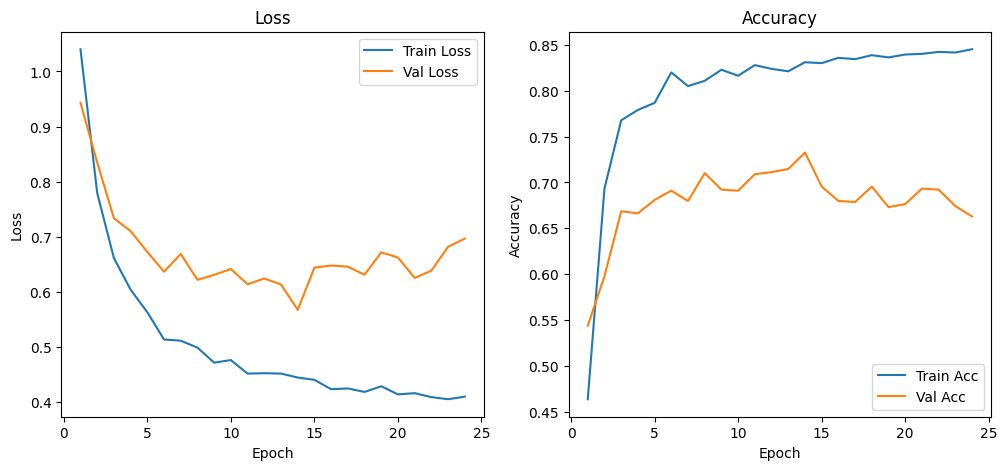

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
syn_loss, syn_acc = eval_model(model, test_loader, criterion, device)

print(f"\nSynthetic Test Loss (LP): {syn_loss:.3f}")
print(f"Synthetic Test Accuracy (LP): {syn_acc:.3f}")

wandb.log({
    "synthetic_acc_lp": syn_acc,
    "synthetic_loss_lp": syn_loss
})

syn_acc_lp = syn_acc

Confusion Matrix - function

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)

Synthetic CM -LP

In [ ]:
y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Synthetic Test (ResNet18-LP)")
plt.show()

fine-tuning

In [ ]:
wandb.init(
    project="plate-classification",
    name="resnet_ ft_augmented",
    config={
        "epochs": 50,
        "batch_size": 16,
        "lr": 1e-4,
        "model": "resnet18",
        "classes": train_dataset.classes
    }
)

In [19]:
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/genai_project/checkpoints"
best_lp_path = os.path.join(CHECKPOINT_DIR, "best_model_lp.pth")
best_ft_path = os.path.join(CHECKPOINT_DIR, "best_model_ft.pth")

# load best LP
model.load_state_dict(torch.load(best_lp_path))
print("Loaded best LP model")

# unfreeze
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

best_val_ft = 0
counter_ft = 0

train_loss_ft, val_loss_ft = [], []
train_acc_ft, val_acc_ft = [], []

for epoch in range(50):

    train_loss_ft, train_acc_ft = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss_ft, val_acc_ft = eval_model(model, val_loader, criterion, device)

    print(f"[FT] Epoch {epoch+1}")
    print(f"Train Loss: {train_loss_ft:.3f} | Train Acc: {train_acc_ft:.3f} | Val Loss: {val_loss_ft:.3f} | Val Acc: {val_acc_ft:.3f}")
    wandb.log({
    "ft_train_loss": train_loss_ft,
    "ft_train_acc": train_acc_ft,
    "ft_val_loss": val_loss_ft,
    "ft_val_acc": val_acc_ft
})

    if val_acc_ft > best_val_ft:
        best_val_ft = val_acc_ft
        counter_ft = 0

        torch.save(model.state_dict(), best_ft_path)
        wandb.save(best_ft_path)

        print("saved best FT model")

    else:
        counter_ft += 1

    if counter_ft >= patience:
        print("Early stopping (FT)")
        break

# load best FT
model.load_state_dict(torch.load(best_ft_path))
print("Loaded best FT model")

FileNotFoundError: [Errno 2] No such file or directory: 'best_model_lp.pth'

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses_ft, label="Train Loss")
plt.plot(epochs_range, val_losses_ft, label="Val Loss")
plt.title("Loss - Fine tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies_ft, label="Train Acc")
plt.plot(epochs_range, val_accuracies_ft, label="Val Acc")
plt.title("Accuracy - Fine tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Synthetic Test

In [ ]:
syn_loss, syn_acc = eval_model(model, test_loader, criterion, device)

print(f"\nSynthetic Test Loss (FT): {syn_loss:.3f}")
print(f"Synthetic Test Accuracy (FT): {syn_acc:.3f}")

wandb.log({
    "synthetic_acc_ft": syn_acc,
    "synthetic_loss_ft": syn_loss
})

syn_acc_ft = syn_acc

Synthetic CM -FT

In [ ]:
y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Synthetic Test (ResNet18-FT)")
plt.show()

In [ ]:
wandb.log({
    "confusion_matrix_synthetic": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_true,
        preds=y_pred,
        class_names=test_dataset.classes
    )
})

CLIP

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

labels_text = [
    "a perfectly clean empty plate",
    "a dirty empty plate with crumbs and stains or few leftover pieces of food",
    "a full plate with a complete meal"
]

CLIP eval

In [ ]:
def clip_predict(image):
    inputs = processor(
        text=labels_text,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

    return probs.argmax().item()


def evaluate_clip(loader):
    correct = 0
    total = 0

    for x, y in loader:
        for i in range(len(x)):
            image = transforms.ToPILImage()(x[i])
            pred = clip_predict(image)

            if pred == y[i].item():
                correct += 1

            total += 1

    return correct / total

clip_syn = evaluate_clip(test_loader)
print(f"CLIP Accuracy (Synthetic DATA): {clip_syn:.3f}")

wandb.log({
    "clip_synthetic_acc": clip_syn,
})

dataset without normalize for CLIP (to avoid RGB normalize)

In [ ]:
clip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()  # בלי normalize!
])

clip_dataset = datasets.ImageFolder(test_dir, transform=clip_transform)
clip_loader = DataLoader(clip_dataset, batch_size=16)

clip_syn = evaluate_clip(clip_loader)
print(f"CLIP Accuracy (Synthetic DATA) without normalize: {clip_syn:.3f}")

FINAL COMPARISON

In [ ]:
print("\n=== FINAL RESULTS ===")
print(f"ResNet LP Synthetic: {syn_acc_lp:.3f}")
print(f"ResNet FT Synthetic: {syn_acc_ft:.3f}")
print(f"CLIP Synthetic:      {clip_syn:.3f}")

In [ ]:
!pip install nbformat

In [ ]:
import nbformat

# notebook name
notebook_path = "/content/drive/MyDrive/genai_project/code/05_train_model.ipynb"

nb = nbformat.read(notebook_path, as_version=4)

# delete widgets metadata if exist
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

# save clean file
clean_path = "/content/drive/MyDrive/genai_project/code/05_train_model_git_version.ipynb"
nbformat.write(nb, clean_path)

print("✅ Clean notebook saved:", clean_path)